# 🔬 RUN_BUENO-STS: Análisis de Runs Individuales STS

**Notebook parametrizable para analizar runs individuales de sensores Frame (STS).**

Basado en la estructura de `RUN_BUENO.ipynb` pero usando `runSTS.py` y con capacidad de filtrar por patrones.

## 📋 Cómo usar

1. **Celda 1**: Setup de paths
2. **Celda 2**: Cargar LogFile
3. **Celda 3**: **MODIFICAR AQUÍ** - Ajusta filtros y selecciona archivo
4. **Celdas 4-7**: Ejecutar análisis

## 🎯 Parámetros (Celda 3)

- `FILENAME_PATTERN = 'STS'` → Filtra por nombre
- `CALIBSET_PATTERN = 'FRAME_SET'` → Filtra por CalibSetNumber
- `EXCLUDE_PATTERNS = ['_pre', 'lar']` → Excluye patrones
- `filename = "..."` → Archivo a analizar

In [1]:
# Add repo root to sys.path so the package can be imported in-kernel without reinstalling
import sys
from pathlib import Path
repo_root = (Path('../..').resolve())  # notebook is RTD_Calibration_VGP/notebooks -> go up 2 levels
sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

# Now you can import modules from the package via the package namespace


Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana


In [2]:
# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.runSTS import Run  # ← Usamos runSTS.py
import pandas as pd

# Read the logfile using repo_root from previous cell
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file
    print("✅ Logfile loaded")
    print(f"   Total rows: {len(logfile_df)}")

CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
✅ Logfile loaded
   Total rows: 792


In [3]:
# ═══════════════════════════════════════════════════════════════
# 🎛️  CONFIGURACIÓN - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

FILENAME_PATTERN = 'STS'           # Filtra por nombre de archivo
CALIBSET_PATTERN = 'FRAME_SET'     # Filtra por CalibSetNumber
EXCLUDE_PATTERNS = ['_pre', 'lar'] # Excluye estos patrones

# ═══════════════════════════════════════════════════════════════
# 🔍 FILTRADO AUTOMÁTICO
# ═══════════════════════════════════════════════════════════════

print(f"\n📊 Aplicando filtros...\n")
filtered_df = logfile_df.copy()

if FILENAME_PATTERN:
    filtered_df = filtered_df[filtered_df['Filename'].str.contains(FILENAME_PATTERN, case=False, na=False)]
    print(f"🔍 Filtro 1: Filename contiene '{FILENAME_PATTERN}' → {len(filtered_df)} archivos")

if CALIBSET_PATTERN:
    filtered_df = filtered_df[filtered_df['CalibSetNumber'].astype(str).str.contains(CALIBSET_PATTERN, case=False, na=False)]
    print(f"🔍 Filtro 2: CalibSetNumber contiene '{CALIBSET_PATTERN}' → {len(filtered_df)} archivos")

for exclude in EXCLUDE_PATTERNS:
    before = len(filtered_df)
    filtered_df = filtered_df[~filtered_df['Filename'].str.contains(exclude, case=False, na=False)]
    excluded = before - len(filtered_df)
    if excluded > 0:
        print(f"🚫 Filtro 3: Excluidos {excluded} archivos con '{exclude}' → {len(filtered_df)} archivos")

print(f"\n📋 Total archivos disponibles: {len(filtered_df)}\n")

if len(filtered_df) > 0:
    print(f"📌 Primeros 10 archivos disponibles:\n")
    for idx, row in filtered_df.head(10).iterrows():
        print(f"   • {row['Filename']}")
        print(f"     Set: {row['CalibSetNumber']} | Selection: {row['Selection']}\n")
    
    if len(filtered_df) > 10:
        print(f"   ... y {len(filtered_df) - 10} archivos más\n")
else:
    print(f"❌ ERROR: No se encontraron archivos")

# ═══════════════════════════════════════════════════════════════
# 📝 SELECCIONAR ARCHIVO ESPECÍFICO
# ═══════════════════════════════════════════════════════════════

# Nombre del archivo a procesar (MODIFICAR para elegir otro)
filename = "20241104_ln2_STSr2_STSr3_STS037_STS048_1"

if filename not in filtered_df['Filename'].values:
    print(f"\n⚠️  WARNING: '{filename}' NO encontrado")
    if len(filtered_df) > 0:
        filename = filtered_df['Filename'].iloc[0]
        print(f"   → Usando primer archivo: {filename}")
    else:
        raise ValueError("No hay archivos disponibles")
else:
    file_info = filtered_df[filtered_df['Filename'] == filename].iloc[0]
    print(f"\n✅ Archivo seleccionado: {filename}")
    print(f"   CalibSetNumber: {file_info['CalibSetNumber']}")
    print(f"   Selection: {file_info['Selection']}")
    print(f"   Date: {file_info['Date']}")


📊 Aplicando filtros...

🔍 Filtro 1: Filename contiene 'STS' → 46 archivos
🔍 Filtro 2: CalibSetNumber contiene 'FRAME_SET' → 46 archivos
🚫 Filtro 3: Excluidos 24 archivos con '_pre' → 22 archivos

📋 Total archivos disponibles: 22

📌 Primeros 10 archivos disponibles:

   • 20220211_ln2_r48178_r48179_sts1_sts2_1
     Set: FRAME_SET1 | Selection: nan

   • 20220428_ln2_r48176_r48177_STS005-STS011_1
     Set: FRAME_SET3 | Selection: TRUE

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_1
     Set: FRAME_SET4 | Selection: BAD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_2
     Set: FRAME_SET4 | Selection: GOOD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_3
     Set: FRAME_SET4 | Selection: GOOD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_4
     Set: FRAME_SET4 | Selection: GOOD

   • 20230531_ln2_STSr1_STSr3_STS025_STS036_1
     Set: FRAME_SET5 | Selection: GOOD

   • 20230602_ln2_STSr1_STSr3_STS025_STS036_2
     Set: FRAME_SET5 | Selection: GOOD

   • 20241104_ln2_STSr2_STSr3_STS037_S

In [4]:
# Create Run instance
print(f"\n🔄 Cargando run: {filename}...\n")

run = Run(filename=filename, logfile=logfile_df)

print("\n✅ Temperature data loaded:")
print(f"   Rows: {len(run.temperature_data)}")
print(f"   Columns: {list(run.temperature_data.columns)}")
print("\n📊 Primeras filas:")
print(run.temperature_data.head())


🔄 Cargando run: 20241104_ln2_STSr2_STSr3_STS037_STS048_1...

Archivo de temperatura encontrado: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Frame_Sensors/CalSetN_F6/20241104_ln2_STSr2_STSr3_STS037_STS048_1.txt
Valores NaN (contador): 0
Empty DataFrame
Columns: [datetime, channel, value]
Index: []
Archivo de temperatura procesado correctamente: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Frame_Sensors/CalSetN_F6/20241104_ln2_STSr2_STSr3_STS037_STS048_1.txt
No se detectaron canales defectuosos.
Valores de sensores extraídos (antes de filtrado y conversión): [  37.   38.   39.   40.   41.   42.   43.   44.   45.   46.   47.   48.
 1002. 1003.]
IDs de sensores después de la conversión: ['37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '1002', '1003']
Asociación de canales con IDs de sensores:
channel_1: Sensor ID 37
channel_2: Sensor ID 38
channel_3: Sensor ID 39
channel_4: Sensor ID 40



🔄 Generando plots...



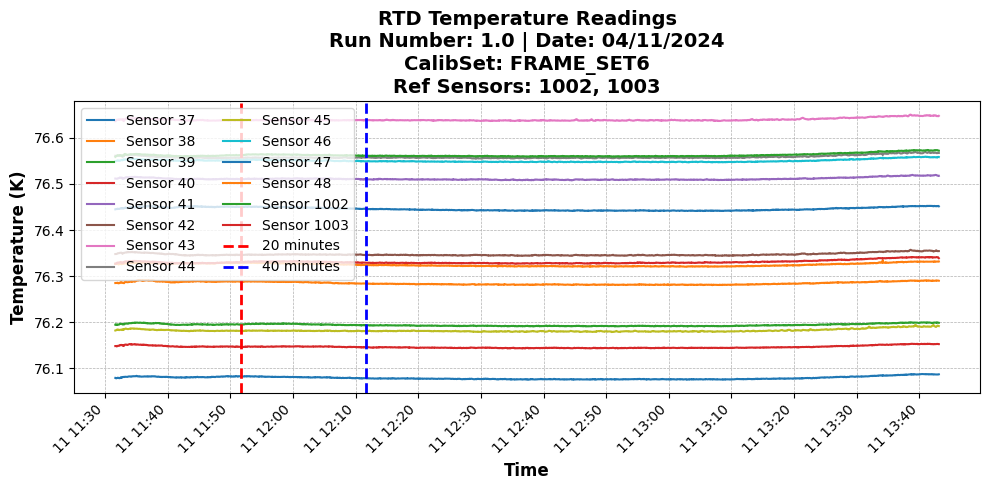

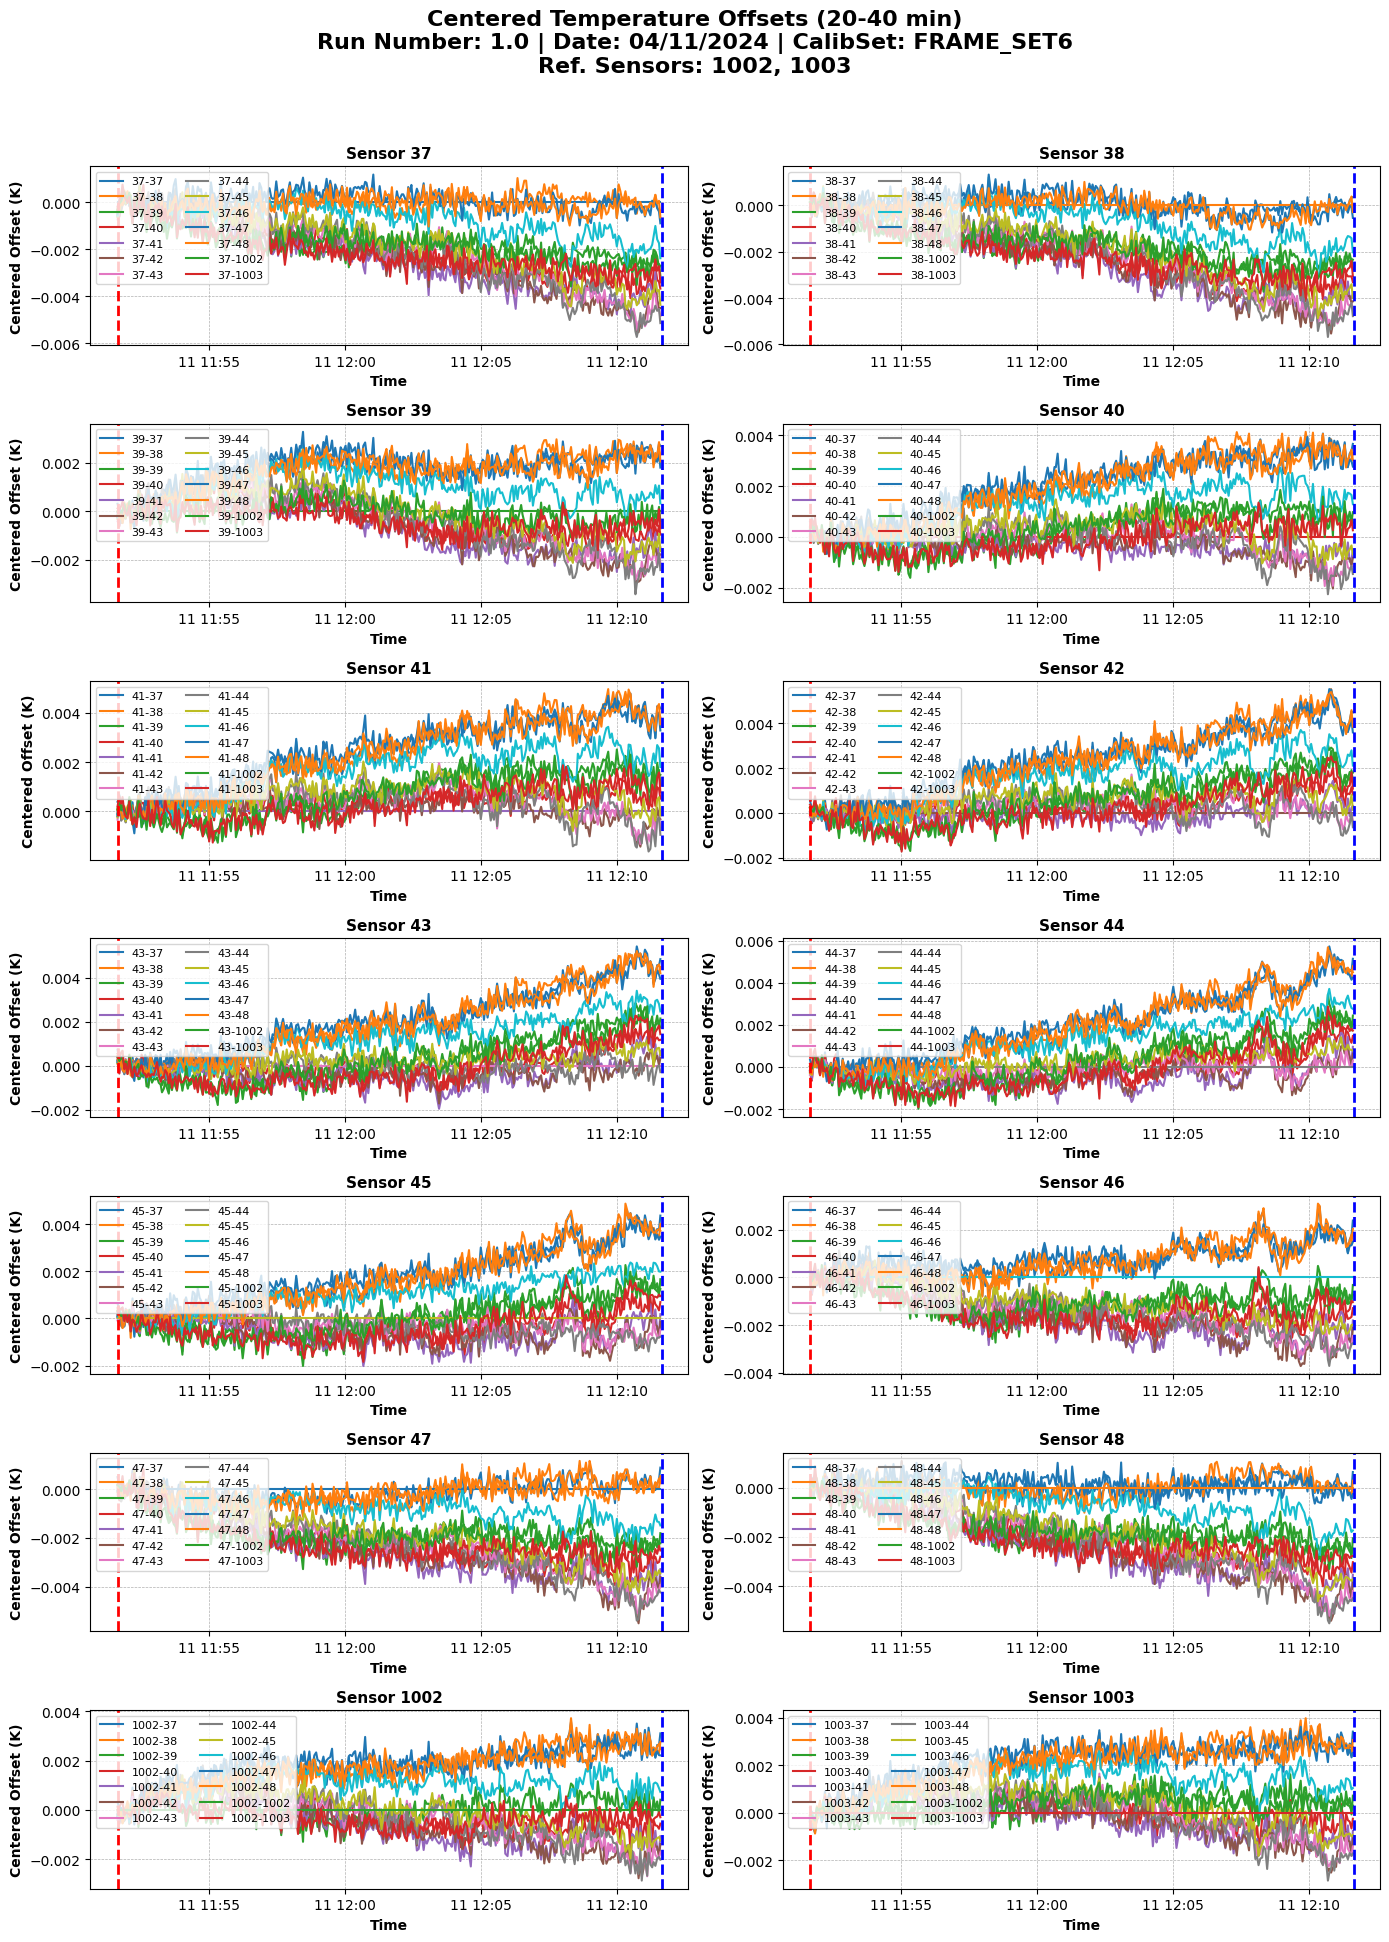

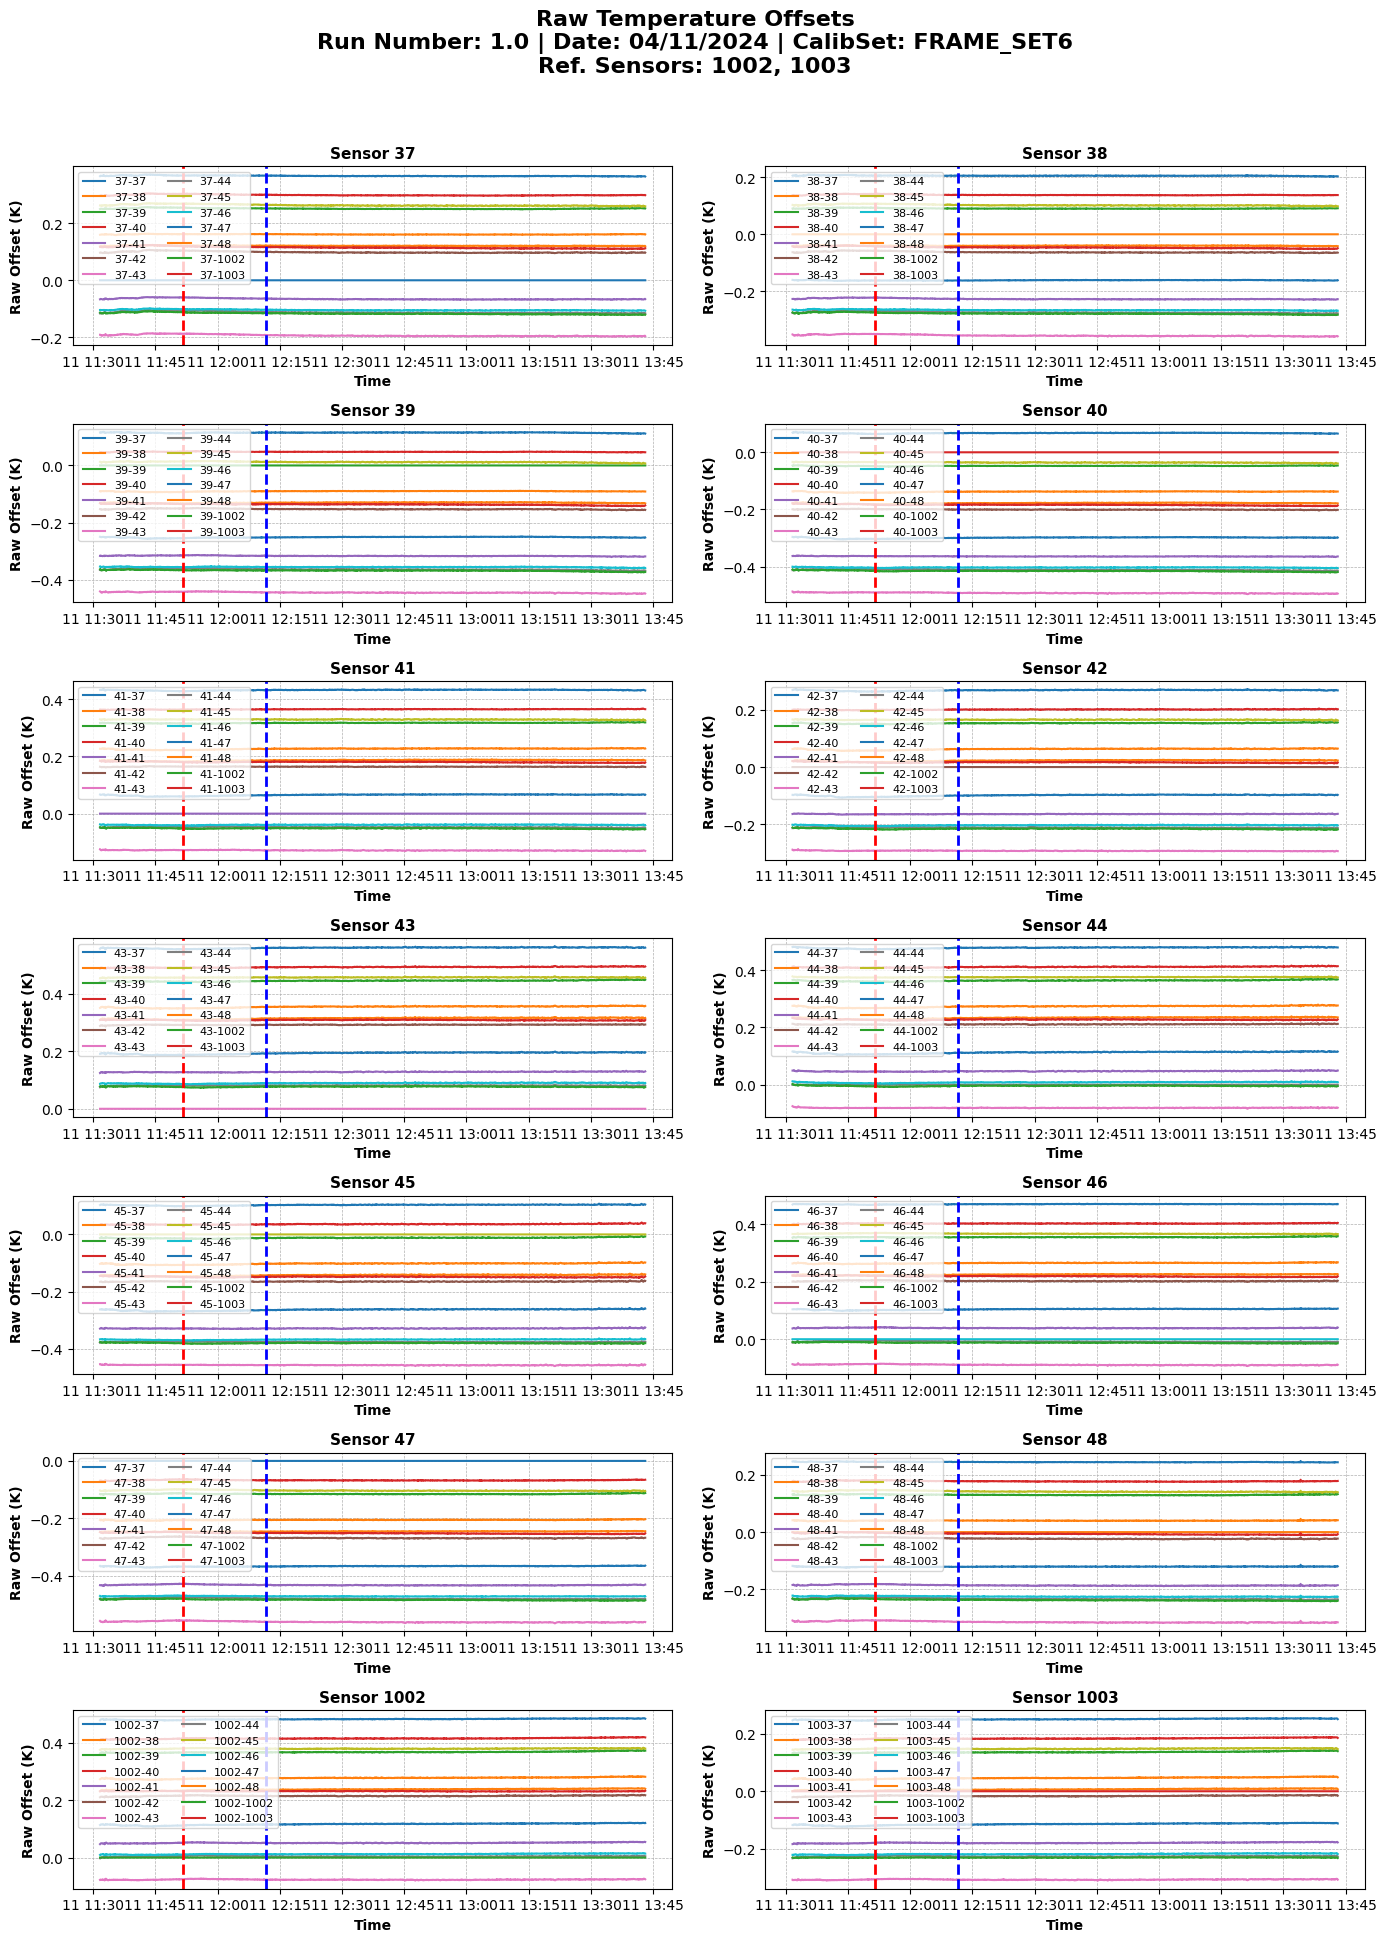

Plots saved in ./Plots/

✅ Plots saved in: ./Plots/


In [5]:
output_dir = "./Plots/"

print(f"\n🔄 Generando plots...\n")
run.save_control_plots(output_dir=output_dir)

print(f"\n✅ Plots saved in: {output_dir}")

In [6]:
print("\n🔄 Calculando offsets...\n")

offsets_df = run.offsets()
print("📊 Matriz de Offsets:")
print(offsets_df)

errors_df = run.stat_err_offsets()
print("\n📊 Errores RMS:")
print(errors_df)


🔄 Calculando offsets...

Offsets medios calculados exitosamente para el run.
📊 Matriz de Offsets:
            37        38        39        40        41        42        43  \
37    0.000000  0.161064  0.251462  0.299077 -0.065208  0.098628 -0.193412   
38   -0.161064  0.000000  0.090398  0.138013 -0.226273 -0.062436 -0.354476   
39   -0.251462 -0.090398  0.000000  0.047615 -0.316670 -0.152834 -0.444874   
40   -0.299077 -0.138013 -0.047615  0.000000 -0.364285 -0.200449 -0.492489   
41    0.065208  0.226273  0.316670  0.364285  0.000000  0.163836 -0.128204   
42   -0.098628  0.062436  0.152834  0.200449 -0.163836  0.000000 -0.292040   
43    0.193412  0.354476  0.444874  0.492489  0.128204  0.292040  0.000000   
44    0.112464  0.273528  0.363926  0.411541  0.047256  0.211092 -0.080948   
45   -0.263435 -0.102370 -0.011973  0.035642 -0.328643 -0.164807 -0.456847   
46    0.104258  0.265323  0.355721  0.403335  0.039050  0.202887 -0.089154   
47   -0.366244 -0.205180 -0.114782 -0.06716


🔄 Generando plot RMS vs tiempo...

Gráfico guardado en: ./Plots/20241104_ln2_STSr2_STSr3_STS037_STS048_1_rms_vs_time.png


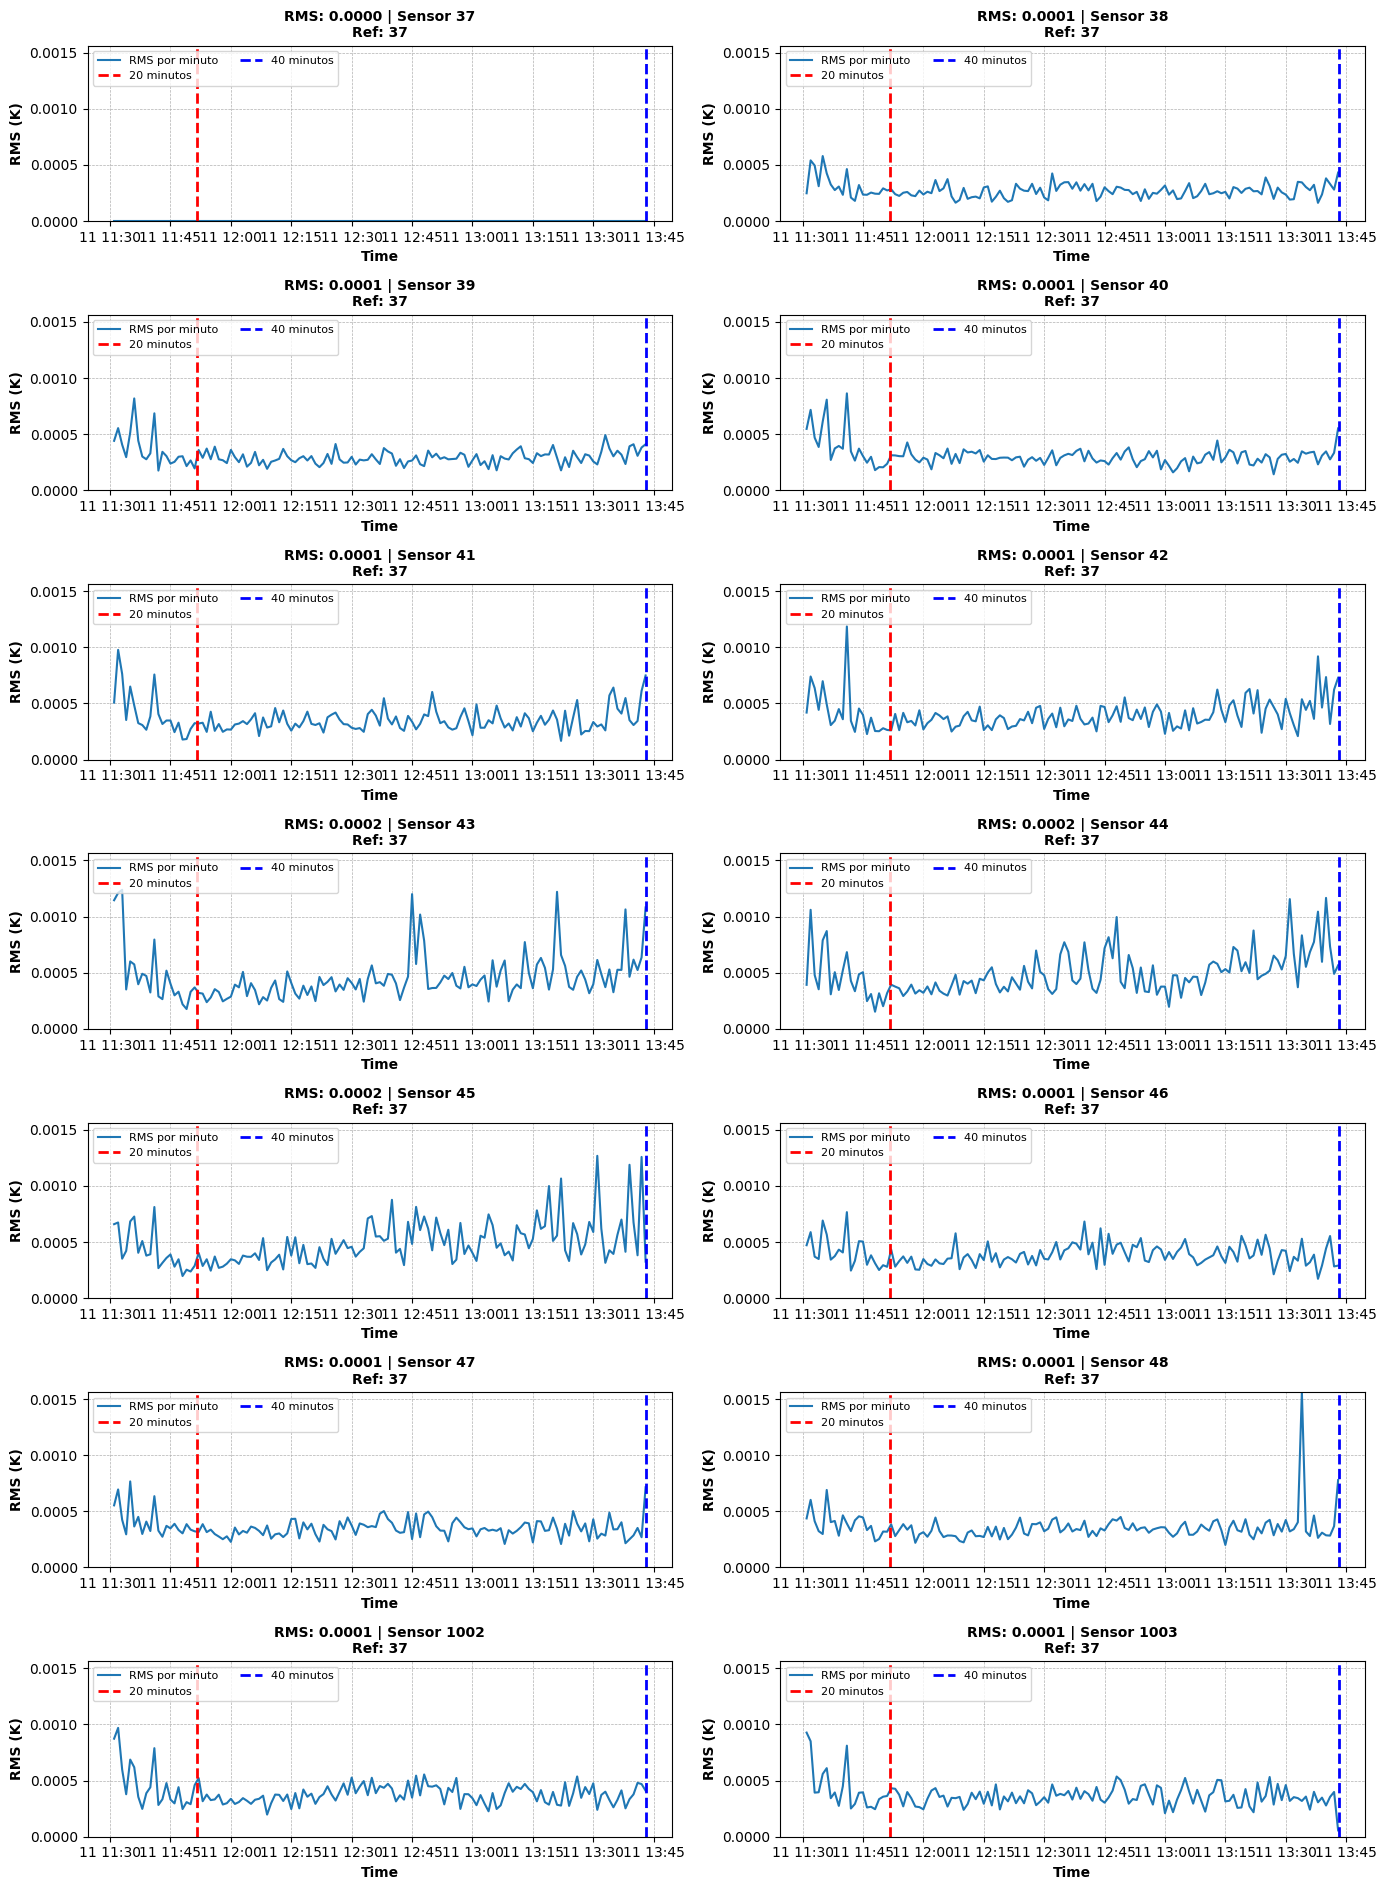


✅ Plot RMS guardado


In [7]:
print("\n🔄 Generando plot RMS vs tiempo...\n")
run.plot_rms_vs_time(output_dir="./Plots/")
print("\n✅ Plot RMS guardado")

In [8]:
# Celda para exploración adicional

# Ver info del run:
# print(f"CalibSetNumber: {run.calib_set_number}")
# print(f"Date: {run.date}")
# print(f"Sensor mapping: {run.sensor_mapping}")

# Ver todos los archivos disponibles:
# for fname in filtered_df['Filename']:
#     print(f"  • {fname}")